# Modeling

## 1. Imports

In [38]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
import numpy as np

## 2. Obtener data

In [39]:
df = pd.read_csv('../data/processed/train_processed.csv')

In [40]:
df.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Lag_4,Rolling_4,Month,Year
0,2015-02-01,2527.914,3092.544,4130.533,4619.108,304.508,3036.67325,2,2015
1,2015-02-08,968.534,2527.914,3092.544,4130.533,4619.108,3592.52475,2,2015
2,2015-02-15,2771.054,968.534,2527.914,3092.544,4130.533,2679.88125,2,2015
3,2015-02-22,224.912,2771.054,968.534,2527.914,3092.544,2340.01150,2,2015
4,2015-03-01,2289.643,224.912,2771.054,968.534,2527.914,1623.10350,3,2015


In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order Date  205 non-null    str    
 1   Sales       205 non-null    float64
 2   Lag_1       205 non-null    float64
 3   Lag_2       205 non-null    float64
 4   Lag_3       205 non-null    float64
 5   Lag_4       205 non-null    float64
 6   Rolling_4   205 non-null    float64
 7   Month       205 non-null    int64  
 8   Year        205 non-null    int64  
dtypes: float64(6), int64(2), str(1)
memory usage: 14.5 KB


Pequeña transformación de Order Date a datetime

In [42]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%Y-%m-%d')

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  205 non-null    datetime64[us]
 1   Sales       205 non-null    float64       
 2   Lag_1       205 non-null    float64       
 3   Lag_2       205 non-null    float64       
 4   Lag_3       205 non-null    float64       
 5   Lag_4       205 non-null    float64       
 6   Rolling_4   205 non-null    float64       
 7   Month       205 non-null    int64         
 8   Year        205 non-null    int64         
dtypes: datetime64[us](1), float64(6), int64(2)
memory usage: 14.5 KB


## 3. Modeling

Este modelado hace referencia a los modelos ML con sus hiperparámetros por defecto

### 3.1 Modelos ML

Diccionario para contener todos los modelos que queremos utilizar.

In [44]:
models_dict = {
    'NaiveModel': None,
    'LinearRegression': LinearRegression(),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor(),
    'RandomForestRegressor': RandomForestRegressor(random_state=42),
    'XGBRegressor': XGBRegressor(),
    'LGBMRegressor': LGBMRegressor(random_state=42, verbose=-1)
}

### 3.2 Separación de X e y

In [45]:
X = df.drop(columns=['Order Date', 'Sales'])
y = df['Sales']

### 3.3 TimeSeriesSplit y evaluar modelos

En este punto lo que pasa es lo siguiente:

Todos los modelos funcionan diferente dependiendo de cuantas semanas tienen para entrenar y cuanto es el test. Por lo que se aplicará TimeSeriesSplit, en donde en n_split=5 es que hará 5 pruebas diferentes, cada una ocupa 10 semanas de test, si tenemos 200 semanas, primero prueba con 150 semanas de train y 10 semanas siguientes de test (serían 160 semanas en total, no toma las otras 40), luego 160 semanas train y 10 de test y asi sucesivamente hasta 190 de train y 10 de test, completando 5 pruebas en total.

Ahora, al ocupar el objeto TimeSeriesSplit y hacerle split a nuestro conjunto de X, va a hacer las 5 separaciones. El _**for**_ de eso entra primero al primer fold, 150 semanas train y 10 test (máximo llega a la semana 160), entonces el train_idx lo único que obtiene son los índices de las 150 semanas, 0,1,2,3,4...149 y test_idx obtiene los índices de las 10 semanas siguientes.

De esa forma en X (features) buscamos los registros del 0 al 149 que seran para el entrenamiento y los del 150 al 159 para el test.

Luego lo mismo para el target (Sales) obtenemos las respuestas para el entrenamiento del 0 al 149, luego las respuestas del 150 al 159.

Luego se entrena el primer modelo del diccionario, se predicen el test y se calcula MAE y RMSE para cada fold, agregando a la lista cada uno de los resultados de los folds con distinto tiempo.

Después al dicicionario se agrega un diccionario con el modelo trabajado, promedio y desviación estandar de MAE y RMSE.

In [46]:
tscv = TimeSeriesSplit(n_splits=5, test_size=10)  # 5 folds, cada uno con 10 semanas de test

# Esta lista es para contener como cada elemento, cada modelo con su MAE Y RMSE (mean y std para cada uno)
resultados_cv = []

for name, model in models_dict.items():
    maes = []
    rmses = []

    # Lógica para el modelo ingenuo, en cada split obtenemos las ventas reales y ventas de la semana pasada, calculamos rendimiento en base a eso
    if model==None:
        for train_idx, test_idx in tscv.split(X):
            y_test = y.iloc[test_idx]
            # Primero desplazamos los resultados 1 hacia abajo para que tenga las ventas de la semana pasada
            y_pred = y.shift(1).iloc[test_idx]

            mae = mean_absolute_error(y_test, y_pred)
            rmse = root_mean_squared_error(y_test, y_pred)

            maes.append(mae)
            rmses.append(rmse)

        resultados_cv.append({
            'modelo': 'NaiveModel',
            'MAE_promedio': np.mean(maes),
            'MAE_std': np.std(maes),
            'RMSE_promedio': np.mean(rmses),
            'RMSE_std': np.std(rmses)
        })

    # Lógica para el resto de modelos
    else:
        for train_idx, test_idx in tscv.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            # Escalar features
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            maes.append(mean_absolute_error(y_test, y_pred))
            rmses.append(root_mean_squared_error(y_test, y_pred))
    
        resultados_cv.append({
            'modelo': name,
            'MAE_promedio': np.mean(maes),
            'MAE_std': np.std(maes),
            'RMSE_promedio': np.mean(rmses),
            'RMSE_std': np.std(rmses)
        })

df_cv = pd.DataFrame(resultados_cv)
df_cv

,modelo,MAE_promedio,MAE_std,RMSE_promedio,RMSE_std
0,NaiveModel,5879.237372,1998.053761,7042.670827,1528.294751
1,LinearRegression,4542.005593,998.415732,5813.693114,1421.632918
2,SVR,7052.600854,4165.060914,8328.301116,4253.204910
3,KNN,4509.867228,1021.859842,5839.780115,1375.836195
4,RandomForestRegressor,4738.041734,1605.722811,6113.989280,1744.299590
5,XGBRegressor,5149.583146,1757.638621,6177.737164,2087.531307
6,LGBMRegressor,4641.425622,1420.710795,5986.664033,1444.690392


### 3.4 Visualizar resultados

In [47]:
stats_columns_names = df_cv.drop(columns=['modelo']).columns

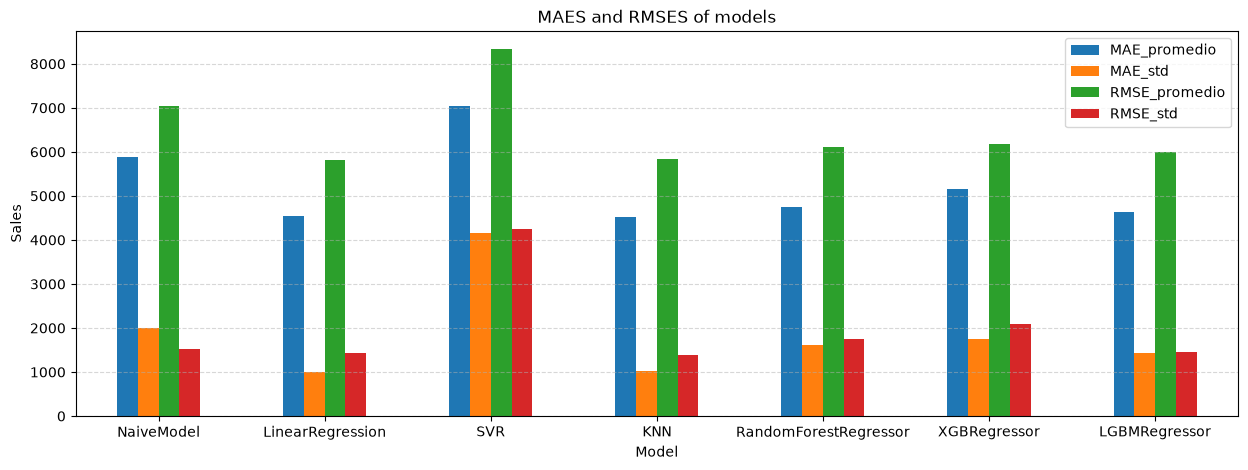

In [48]:
ax = df_cv.plot(
    kind='bar',
    x='modelo',
    y=stats_columns_names,
    figsize=(15, 5)
)

plt.title('MAES and RMSES of models')
plt.xlabel('Model')
plt.ylabel('Sales')

# Ajustar grid de forma manual
ax.grid(
    axis='y',
    alpha=0.5,
    linestyle='--'
)

ax.legend(bbox_to_anchor=(1, 1))

plt.tick_params(rotation=0)

## 5. Modeling 2

En esta parte lo que vamos a hacer es buscar el mejor tuning para los modelos más complejos, mediante GridSearchCV. Al contrario que el primer modelado, aquí trabajaremos con los mejores hiperparámetros para los datos.

### 5.1 Separar X e y

In [49]:
X = df.drop(columns=['Order Date', 'Sales'])
y = df['Sales']

Primero separamos las semanas que vamos a querer predecir finalmente y con las que vamos a trabajar

In [50]:
# Semanas con las que entrenaremos (aprox 0-200)
X_train = X[:-10]
y_train = y[:-10]

# Semanas de prueba final (aprox 200-210)
X_test = X[-10:]
y_test = y[-10:]

### 5.2 Modelos a probar

In [51]:
models_dict = {
    'LinearRegression': LinearRegression(),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor(),
    'RandomForestRegressor': RandomForestRegressor(random_state=42),
    'XGBRegressor': XGBRegressor(),
    'LGBMRegressor': LGBMRegressor(random_state=42, verbose=-1)
}

### 5.3 Parámetros a probar en cada modelo

Cada elemento del diccionario, es otro diccionario con el nombre del modelo como key y sus parámetros para probar, esto va a ir a un Pipeline entonces indicamos primero la etapa donde ajustar tales hiperparámetros

In [52]:
param_grids = {
    # No tiene parámetros muy buenos para cambiar
    'LinearRegression':{},

    # Modelos mas complejos
    'SVR': {
        'model__C': [0.1, 1, 10, 100],
        'model__kernel': ['linear', 'rbf']
    },

    'KNN': {
        'model__n_neighbors': [3, 5, 10, 15],
        'model__weights': ['uniform', 'distance'],
        'model__p': [1, 2]
    },

    'RandomForestRegressor': {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5, 10]
    },

    'XGBRegressor': {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [3, 5, 7],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__subsample': [0.8, 1.0]
    },

    'LGBMRegressor': {
        'model__n_estimators': [100, 200, 300],
        'model__num_leaves': [15, 31, 63],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [-1, 5, 10]
    }
}

### 5.4 Particiones para que el modelo pruebe

Cada modelo va a probar cada combinación de sus hiperparámetros para primero 150 semanas y estimar las próximas 10, luego 160 y 10, 170 y 10. Hasta 190 y 10.

In [53]:
tscv = TimeSeriesSplit(n_splits=5, test_size=10)

### 5.5 Flujo entrenamiento con TimeSeriesSplit y GridSearchCV

Crear CV para contener los resultados de los modelos y luego convertirlo a un DataFrame

In [54]:
resultados_cv = []

Diccionario para guardar los mejores modelos entrenados

In [55]:
models_trained = {}

Pensar que para buscar los resultados de los splits en el mejor parametro, se busca algo de esta forma (cv_results_) tiene algo como esto:

|índice del estimator| params | split0_test_score | split1_test_score | split2_test_score | split3_test_score | split4_test_score | mean |
|--------------------|--------|-------------------|-------------------|-------------------|-------------------|-------------------|------|
|         1          | n=100  |  -100  |  -120  |  -110  |  -125  |  -105  | -112 |
|         2          | n=100  |  -100  |  -120  |  -110  |  -125  |  -105  | -112 |
|         3          | n=100  |  -100  |  -120  |  -110  |  -125  |  -105  | -112 |

Entonces podemos buscar en cv_results_ el indice del mejor estimator, ya estando ahi podemos obtener los valores de sus splits

In [56]:
for model_name, model_object in models_dict.items():

    #Crear Pipeline, estandariza y utiliza cada modelo ML en cada iteración
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model_object)
    ])

    # Si dentro de param_grids el modelo actual no tiene nada, entra (por lo que es el modelo lineal)
    # Entonces probamos el modelo lineal para distintos escenarios (150/10), (160/10)...(190/10)
    if not param_grids[model_name]:
        maes_linear = []
        for train_idx, val_idx in tscv.split(X_train):
            # Datos de entrenamiento para el modelo
            X_train_fold = X_train.iloc[train_idx]
            y_train_fold = y_train.iloc[train_idx]

            # Datos para hacer predicciones (aquí van los 10)
            X_val_fold = X_train.iloc[val_idx]
            y_val_fold = y_train.iloc[val_idx]


            # Entrenar modelo con esos datos y guardar sus mse y rmse (recordar que en el pipeline ya esta cargado el modelo actual (LinearRegression))
            pipeline.fit(X_train_fold, y_train_fold)

            # Hacer predicciones de las 10 semanas que vengan
            y_pred_linear = pipeline.predict(X_val_fold)

            # Evaluar MAE y guardarlo para calcular sus promedios
            mae = mean_absolute_error(y_val_fold, y_pred_linear)
            rmse = root_mean_squared_error(y_val_fold, y_pred_linear)
            maes_linear.append(mae)
        
        # Una vez con todos los splits hechos, guardamos en resultados_cv un registro con el modelo, mean de MAE y mean de RMSE
        resultados_cv.append({
            'model': model_name,
            'MAE_mean': np.mean(maes_linear),
            'MAE_std': np.std(maes_linear)
        })

        # Ahora si entrenar con todos los datos de entrenamiento
        pipeline.fit(X_train, y_train)

        # Guardar el modelo en el diccionario
        models_trained[model_name] = pipeline

    # Flujo para el resto de modelos, en esta parte ya sabemos que estamos en un modelo complejo
    else:
        # Creamos el GridSearchCV, ojo acá, el estimador va a ser el pipeline (convertirá la info escalandola primero), luego aplica el modelo ML
        # Como es GridSearchCV va a buscar con que grid probar los hiperparámetros, le decimos que pruebe con los que tiene la key del nombre del modelo
        # Luego para hacer las pruebas separa en splits, con la forma del TimeSeriesSplit (150, 10), (160, 10)...(190, 10), aunque eso aun no lo sabe, solo sabe
        # que tiene que hacer 5 divisiones con 10 registros/indices reservados para la prueba
        # Luego se le indica que es lo que tiene que MAXIMIZAR, como va a buscar el valor mas alto, le decimos que busque el error absoluto promedio pero negativo
        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grids[model_name],
            cv=tscv,
            scoring='neg_mean_absolute_error',
            n_jobs=-1
        )

        # Entrenar el modelo. Aqui simplemente X_train e y_train porque de por si va a hacer la separacion internamente por tscv
        grid_search.fit(X_train, y_train)

        # Ahora, veremos los valores que obtuvo el mejor modelo posible para obtener neg_mean_absolute_error
        # Entonces en cv_results_ podemos ir a sus columnas split0_test_score, split1_test_score... y especificamente del índice del mejor estimator
        best_index = grid_search.best_index_

        # Aquí guardaremos en una lista cada uno de los resultados
        scores_best_estimator = [
            grid_search.cv_results_['split0_test_score'][best_index],
            grid_search.cv_results_['split1_test_score'][best_index],
            grid_search.cv_results_['split2_test_score'][best_index],
            grid_search.cv_results_['split3_test_score'][best_index],
            grid_search.cv_results_['split4_test_score'][best_index],
        ]

        # Calcular MAE para este estimator en específico, primero pasaremos los valores negativos a positivos
        scores_best_estimator = np.abs(scores_best_estimator)
        # Agregar resultados al cv
        resultados_cv.append({
            'model': model_name,
            'MAE_mean': np.mean(scores_best_estimator),
            'MAE_std': np.std(scores_best_estimator)
        })

        # Guardar el modelo en el diccionario
        # Detalle: con GridSearchCV luego de haber pasado por los 5 folds, el modelo vuelve a entrenar otra vez, con el conjunto
        # entero, por ello no es necesario reentrenar el best_estimator_ con todos los datos
        models_trained[model_name] = grid_search.best_estimator_


### 5.6 Agregar un NaiveModel

Spliteamos en X_train para que obtenga los mismos registros para entrenamiento y prueba (150, 10), (160, 10)

En los Sales de entrenamiento, buscamos las respuestas. Luego predecimos siempre los valores de la semana pasada.

In [57]:
maes_naive = []

for _, test_idx in tscv.split(X_train):

    y_true = y_train.iloc[test_idx]
    y_pred_naive = y_train.shift(1).iloc[test_idx]

    maes_naive.append(mean_absolute_error(y_true, y_pred_naive))

# Agregar al cv los resultados del NaiveModel
resultados_cv.append({
    'model': 'NaiveModel',
    'MAE_mean': np.mean(maes_naive),
    'MAE_std': np.std(maes_naive)
})


### 5.7 Crear DataFrame

In [58]:
df_cv = pd.DataFrame(resultados_cv)
df_cv

,model,MAE_mean,MAE_std
0,LinearRegression,4281.424464,542.760387
1,SVR,4301.620373,1084.624498
2,KNN,4298.929120,1059.388965
3,RandomForestRegressor,4435.899421,1318.260348
4,XGBRegressor,4497.163714,1647.904579
5,LGBMRegressor,4604.930328,1392.128518
6,NaiveModel,5199.005356,1021.759563


### 5.8 Visualizar resultados

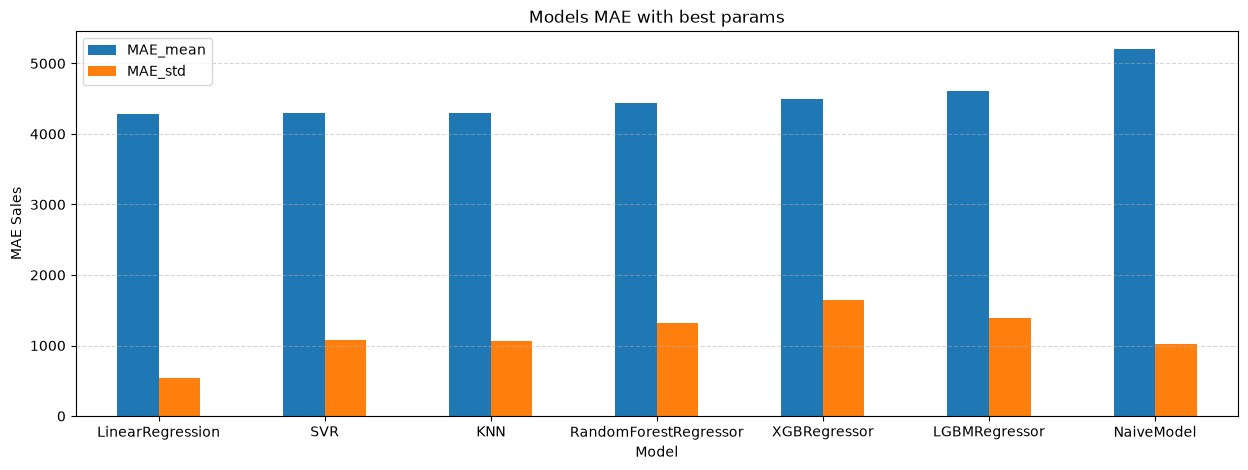

In [59]:
ax = df_cv.plot(
    kind='bar',
    x='model',
    y=['MAE_mean', 'MAE_std'],
    figsize=(15, 5)
)

plt.title('Models MAE with best params')

plt.xlabel('Model')
plt.ylabel('MAE Sales')

ax.grid(
    alpha=0.5,
    linestyle='--',
    axis='y'
)

plt.tick_params(rotation=0)

plt.show()

## 6. Predictions

### 6.1 Realizar predicciones y guardarlas

Aquí nos enfrentamos a un problema, los modelos esperan obtener los lags y rolling. Pero si queremos predecir desde el registro 201 al 210, en el 210 no podemos saber las ventas de la semana pasada (lags) y menos el promedio de las 4 últimas semanas (rolling).

Para poder abarcar este problema, lo que vamos a hacer es predecir de forma recursiva. Es decir predeciremos las ventas del dia 201 y así esa venta funciona como el Lag_1 de las ventas para el 202.

In [60]:
X_train.head()

,Lag_1,Lag_2,Lag_3,Lag_4,Rolling_4,Month,Year
0,3092.544,4130.533,4619.108,304.508,3036.67325,2,2015
1,2527.914,3092.544,4130.533,4619.108,3592.52475,2,2015
2,968.534,2527.914,3092.544,4130.533,2679.88125,2,2015
3,2771.054,968.534,2527.914,3092.544,2340.01150,2,2015
4,224.912,2771.054,968.534,2527.914,1623.10350,3,2015


Diccionario para almacenar las predicciones de cada modelo

In [61]:
models_predictions_dict = {
    'LinearRegression': [],
    'SVR': [],
    'KNN': [],
    'RandomForestRegressor': [],
    'XGBRegressor': [],
    'LGBMRegressor': []
}

Entonces recorremos cada modelo ya entrenado.

In [62]:
for model_name, model_object in models_trained.items():
    # Historial de ventas, digamos que tenemos las ventas desde la 0 a la 200
    historial = list(y_train)

    # Del DataFrame obtenemos las fechas que queremos predecir
    fechas_prediccion = df['Order Date'].iloc[-(len(y_test)):]

    # Sabemos que predeciremos las 10 semanas siguientes, pero por términos de reproducción haremos este proceso
    # tantas veces como el largo del test, asi la primera vez que entra es para predecir la primera semana
    for i in range(len(y_test)):

        # Creamos el DataFrame para predecir la siguiente semana
        X_info = pd.DataFrame({
            # Lags (ventas de x semanas antes)
            'Lag_1': [historial[-1]],
            'Lag_2': [historial[-2]],
            'Lag_3': [historial[-3]],
            'Lag_4': [historial[-4]],
            # Promedio de las 4 semanas anteriores
            'Rolling_4': [np.mean(historial[-4:])],
            # Mes y año del registro que se esta recorriendo que se quiere predecir
            'Month': fechas_prediccion.iloc[i].month,
            'Year': fechas_prediccion.iloc[i].year
        })

        # Conociendo las ventas de las semanas pasadas (Lag_1, Lag_2...) el promedio, el mes a predecir y el año
        # podemos generar una predicción
        # Ojo, recordar que como estamos haciendo predict, el modelo devuelve un array de numpy (porque aunque estemos
        # prediciendo 1 sola semana, podria predecir varias semanas al mismo tiempo, entonces lo que hay que hacer
        # es pedirle a array que devolvió, el primer elemento)
        prediction = model_object.predict(X_info)[0]

        # La primera vez que entra a este loop, se predica la "semana 201"
        # Por lo que ahora podemos guardar esa predicción en el historial, asi cuando vuelva a entrar en este loop
        # para predecir la semana 202, el historial[-1] ya de por si va a ser lo predicho en la semana 201
        historial.append(prediction)

        # Ahora guardamos en el diccionario de predicciones cada prediccion del modelo
        # Ojo que para el diccionario lo guardamos como float, ya que si no, siguen siendo float de numpy
        models_predictions_dict[model_name].append(float(prediction))
        
print(models_predictions_dict)



{'LinearRegression': [15968.938112148131, 16474.39921090022, 17407.514515201678, 17668.182828763853, 17537.065248998624, 18408.429674672538, 18405.00864818517, 18476.19734144482, 18441.919172735677, 18373.392740058738], 'SVR': [13860.970579635374, 14323.407529526012, 14460.293992335222, 14525.897721855927, 14551.87556507716, 15193.214795295275, 15322.008484885466, 15404.628423164002, 15432.83734527168, 15446.435246573794], 'KNN': [19208.378666666667, 18674.59176666667, 18674.59176666667, 19208.378666666667, 19522.232, 19522.232, 19522.232, 19522.232, 19522.232, 19522.232], 'RandomForestRegressor': [17002.044123017895, 18272.486138427146, 15179.056782840393, 20427.248574936366, 17559.20842456604, 16277.832738560091, 21081.081641253037, 17953.550363043425, 18928.686642893426, 21535.726376161376], 'XGBRegressor': [14925.9423828125, 20258.8203125, 16145.0908203125, 17640.57421875, 19311.025390625, 19434.822265625, 19349.8515625, 19357.458984375, 18439.134765625, 19165.4921875], 'LGBMRegres

### 6.2 Evaluar predicciones con visualizaciones

#### 6.2.1 Integrar a info a DataFrames

Para mas comodidad convertiremos las predicciones a DataFrame y también agregaremos el modelo ingenuo

In [63]:
df_predictions = pd.DataFrame(models_predictions_dict)

y_pred_naive = df['Sales'].shift(1)[-len(y_pred):].values
df_predictions['NaiveModel'] = y_pred_naive

df_predictions

,LinearRegression,SVR,KNN,RandomForestRegressor,XGBRegressor,LGBMRegressor,NaiveModel
0,15968.938112,13860.970580,19208.378667,17002.044123,14925.942383,15798.968965,13270.8182
1,16474.399211,14323.407530,18674.591767,18272.486138,20258.820312,18230.039130,21535.2700
2,17407.514515,14460.293992,18674.591767,15179.056783,16145.090820,16241.842008,29017.4670
3,17668.182829,14525.897722,19208.378667,20427.248575,17640.574219,18479.936417,20015.5500
4,17537.065249,14551.875565,19522.232000,17559.208425,19311.025391,18275.539720,30572.4470
5,18408.429675,15193.214795,19522.232000,16277.832739,19434.822266,17850.208829,22212.7690
6,18405.008648,15322.008485,19522.232000,21081.081641,19349.851562,17645.812132,35998.9000
7,18476.197341,15404.628423,19522.232000,17953.550363,19357.458984,17645.812132,21537.2410
8,18441.919173,15432.837345,19522.232000,18928.686643,18439.134766,17645.812132,11542.8340
9,18373.392740,15446.435247,19522.232000,21535.726376,19165.492188,17850.208829,19457.0680


In [64]:
df.tail(len(y_test))

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Lag_4,Rolling_4,Month,Year
195,2018-10-28,21535.2700,13270.8182,16509.8310,21535.5940,12296.0620,15903.07630,10,2018
196,2018-11-04,29017.4670,21535.2700,13270.8182,16509.8310,21535.5940,18212.87830,11,2018
197,2018-11-11,20015.5500,29017.4670,21535.2700,13270.8182,16509.8310,20083.34655,11,2018
198,2018-11-18,30572.4470,20015.5500,29017.4670,21535.2700,13270.8182,20959.77630,11,2018
199,2018-11-25,22212.7690,30572.4470,20015.5500,29017.4670,21535.2700,25285.18350,11,2018
200,2018-12-02,35998.9000,22212.7690,30572.4470,20015.5500,29017.4670,25454.55825,12,2018
201,2018-12-09,21537.2410,35998.9000,22212.7690,30572.4470,20015.5500,27199.91650,12,2018
202,2018-12-16,11542.8340,21537.2410,35998.9000,22212.7690,30572.4470,27580.33925,12,2018
203,2018-12-23,19457.0680,11542.8340,21537.2410,35998.9000,22212.7690,22822.93600,12,2018
204,2018-12-30,15210.8858,19457.0680,11542.8340,21537.2410,35998.9000,22134.01075,12,2018


DataFrame completo a predecir (test) (para comparar con predicciones)

In [65]:
df_to_predict = df.iloc[-len(y_test):]
df_to_predict

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Lag_4,Rolling_4,Month,Year
195,2018-10-28,21535.2700,13270.8182,16509.8310,21535.5940,12296.0620,15903.07630,10,2018
196,2018-11-04,29017.4670,21535.2700,13270.8182,16509.8310,21535.5940,18212.87830,11,2018
197,2018-11-11,20015.5500,29017.4670,21535.2700,13270.8182,16509.8310,20083.34655,11,2018
198,2018-11-18,30572.4470,20015.5500,29017.4670,21535.2700,13270.8182,20959.77630,11,2018
199,2018-11-25,22212.7690,30572.4470,20015.5500,29017.4670,21535.2700,25285.18350,11,2018
200,2018-12-02,35998.9000,22212.7690,30572.4470,20015.5500,29017.4670,25454.55825,12,2018
201,2018-12-09,21537.2410,35998.9000,22212.7690,30572.4470,20015.5500,27199.91650,12,2018
202,2018-12-16,11542.8340,21537.2410,35998.9000,22212.7690,30572.4470,27580.33925,12,2018
203,2018-12-23,19457.0680,11542.8340,21537.2410,35998.9000,22212.7690,22822.93600,12,2018
204,2018-12-30,15210.8858,19457.0680,11542.8340,21537.2410,35998.9000,22134.01075,12,2018


Añadir fechas al DataFrame con las predicciones

In [66]:
df_predictions['Order Date'] = df_to_predict['Order Date'].values
df_predictions

,LinearRegression,SVR,KNN,RandomForestRegressor,XGBRegressor,LGBMRegressor,NaiveModel,Order Date
0,15968.938112,13860.970580,19208.378667,17002.044123,14925.942383,15798.968965,13270.8182,2018-10-28
1,16474.399211,14323.407530,18674.591767,18272.486138,20258.820312,18230.039130,21535.2700,2018-11-04
2,17407.514515,14460.293992,18674.591767,15179.056783,16145.090820,16241.842008,29017.4670,2018-11-11
3,17668.182829,14525.897722,19208.378667,20427.248575,17640.574219,18479.936417,20015.5500,2018-11-18
4,17537.065249,14551.875565,19522.232000,17559.208425,19311.025391,18275.539720,30572.4470,2018-11-25
5,18408.429675,15193.214795,19522.232000,16277.832739,19434.822266,17850.208829,22212.7690,2018-12-02
6,18405.008648,15322.008485,19522.232000,21081.081641,19349.851562,17645.812132,35998.9000,2018-12-09
7,18476.197341,15404.628423,19522.232000,17953.550363,19357.458984,17645.812132,21537.2410,2018-12-16
8,18441.919173,15432.837345,19522.232000,18928.686643,18439.134766,17645.812132,11542.8340,2018-12-23
9,18373.392740,15446.435247,19522.232000,21535.726376,19165.492188,17850.208829,19457.0680,2018-12-30


#### 6.2.2 Visualizar con gráfico de líneas

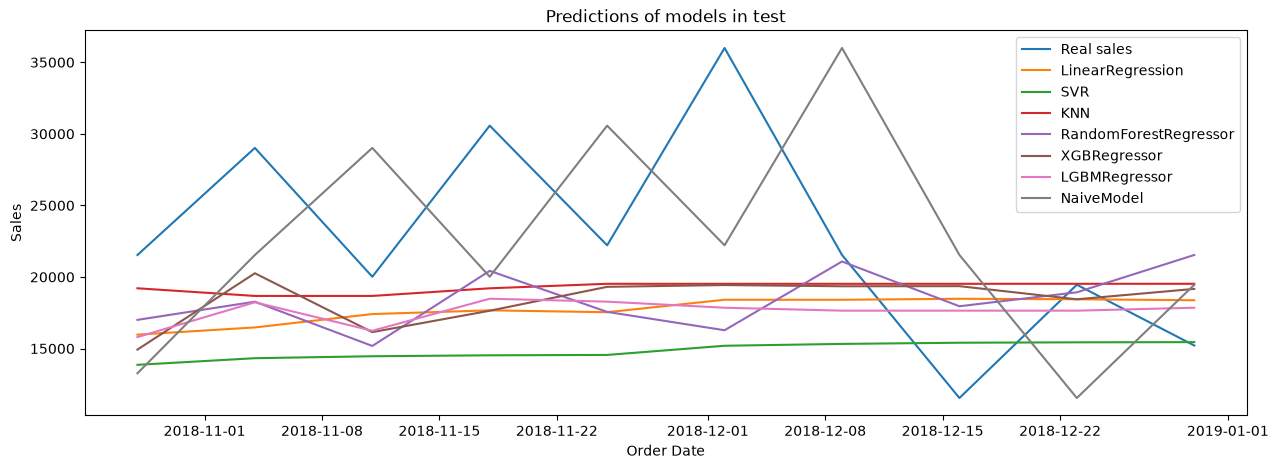

In [67]:
plt.figure(figsize=(15, 5))

plt.plot(
    df_to_predict['Order Date'],
    df_to_predict['Sales'],
    label='Real sales'
)

for model_name in df_predictions.drop(columns=['Order Date']).columns:
    plt.plot(
    df_predictions['Order Date'],
    df_predictions[model_name],
    label=model_name
)

plt.legend()

plt.title('Predictions of models in test')
plt.xlabel('Order Date')
plt.ylabel('Sales')

plt.show()

#### 6.2.3 Visualizar MAE y RMSE

Lista para almacenar MAE y RMSE de los modelos

In [68]:
best_models_mae_rmse_list = []

Iterar sobre cada nombre de las columnas del DataFrame con las predicciones

In [ ]:
for model_name in df_predictions.drop(columns=['Order Date']).columns:
    mae = mean_absolute_error(df_to_predict['Sales'], df_predictions[model_name])
    rmse = root_mean_squared_error(df_to_predict['Sales'], df_predictions[model_name])

    best_models_mae_rmse_list.append({
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse
    })

# Convertir los resultados en DataFrame
df_best_models_mae_rmse = pd.DataFrame(best_models_mae_rmse_list)

Visualizar

In [70]:
df_best_models_mae_rmse

,Model,MAE,RMSE
0,LinearRegression,7013.112487,8728.320107
1,SVR,8677.354986,10604.344302
2,KNN,5891.291533,7799.822391
3,RandomForestRegressor,6835.462387,8686.113913
4,XGBRegressor,6661.068165,8172.685081
5,LGBMRegressor,6892.085383,8469.099327
6,NaiveModel,9406.775400,9830.572512


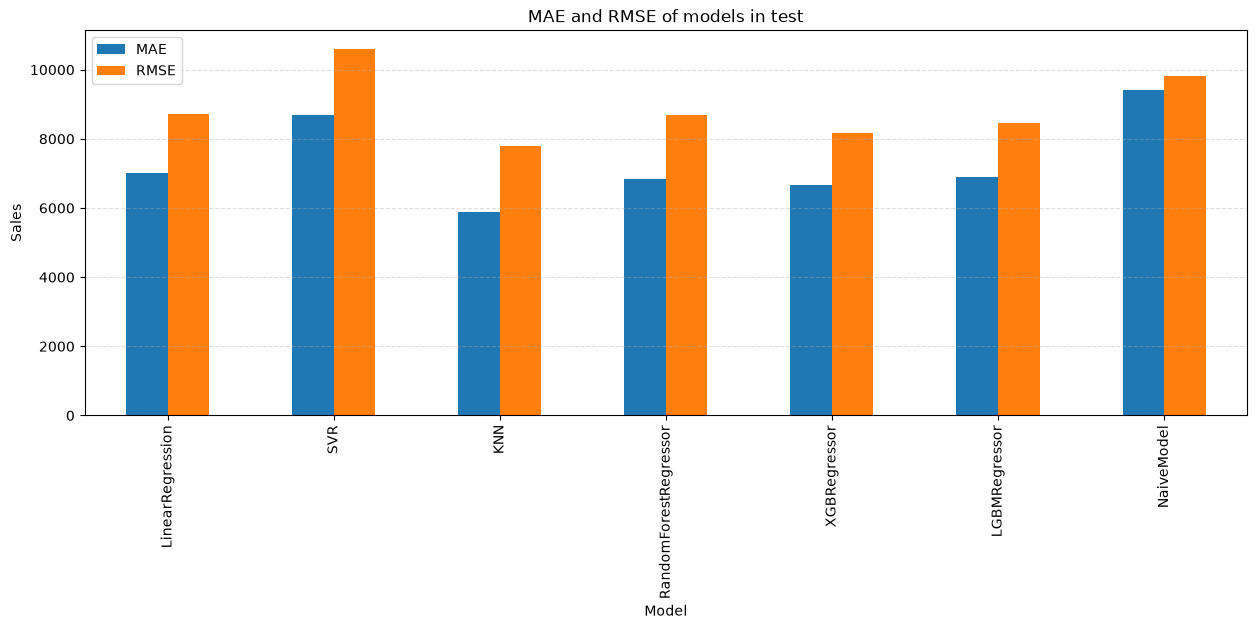

In [71]:
ax = df_best_models_mae_rmse.plot(
    kind='bar',
    x='Model',
    y=['MAE', 'RMSE'],
    figsize=(15, 5)
)

ax.grid(
    alpha=0.4,
    linestyle='--',
    axis='y'
)

plt.title('MAE and RMSE of models in test')
plt.xlabel('Model')
plt.ylabel('Sales')

plt.show()